# KÜTÜPHANELER, GPU AYARI VE 6 SINIFLI VERİ BÖLÜNME

In [ ]:
import os
import time
import shutil
import random
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LSTM, TimeDistributed, GlobalAveragePooling2D,
    Conv2D, MaxPooling2D, BatchNormalization, Flatten
)
from tensorflow.keras.applications import (
    InceptionV3, VGG16, ResNet50, DenseNet121, EfficientNetB0
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import kagglehub
import warnings

warnings.filterwarnings('ignore')

# GPU Bellek Taşmasını Önleme
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Bellek Büyümesi aktif edildi.")
    except RuntimeError as e:
        print(f"GPU Ayar Hatası: {e}")

print("\nVeri seti indiriliyor...")
dataset_path = kagglehub.dataset_download('sriramr/fruits-fresh-and-rotten-for-classification')
BASE_DIR = os.path.join(dataset_path, "dataset")

# 6 SINIFLI KATEGORİLER
CLASS_NAMES = ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
LABEL_MAP = {c: i for i, c in enumerate(CLASS_NAMES)}

print("Veriler toplanıyor...")
all_paths, all_labels = [], []
for split_dir in ["train", "test"]:
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(BASE_DIR, split_dir, cls)
        if not os.path.isdir(cls_dir): continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(cls_dir, fname))
                all_labels.append(LABEL_MAP[cls])

all_paths, all_labels = np.array(all_paths), np.array(all_labels)

# 70/10/20 Kusursuz Bölünme (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(all_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.667, random_state=42, stratify=y_temp)

WORK_DIR = "./working_6class"
TRAIN_DIR_OUT, VAL_DIR_OUT, TEST_DIR_OUT = [os.path.join(WORK_DIR, s) for s in ["train", "val", "test"]]

def write_dataset_dirs(paths, labels, base_out):
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(base_out, cls), exist_ok=True)
    for p, lbl in zip(paths, labels):
        cls_name = CLASS_NAMES[lbl]
        shutil.copy2(p, os.path.join(base_out, cls_name, os.path.basename(p)))

print("Fiziksel 6 sınıflı klasörler oluşturuluyor (Biraz sürebilir)...")
write_dataset_dirs(X_train, y_train, TRAIN_DIR_OUT)
write_dataset_dirs(X_val,   y_val,   VAL_DIR_OUT)
write_dataset_dirs(X_test,  y_test,  TEST_DIR_OUT)

GPU Bellek Büyümesi aktif edildi.

Veri seti indiriliyor...
Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
Veriler toplanıyor...
Fiziksel 6 sınıflı klasörler oluşturuluyor (Biraz sürebilir)...


# HİPERPARAMETRELER VE JENERATÖRLER


In [ ]:
BATCH_SIZE = 64
EPOCHS = 30 # Hızlı sonuç için 30 epoch (Makale standardı 50)
SEQ_LEN = 5

# 1. Augmentasyon İÇEREN Jeneratör (Makaledeki gibi)
train_datagen_aug = ImageDataGenerator(
    rescale=1.0/255, rotation_range=30, horizontal_flip=True, vertical_flip=True,
    zoom_range=0.10, brightness_range=[0.75, 1.25], fill_mode='nearest'
)

# 2. Augmentasyon İÇERMEYEN Jeneratör (Ablasyon Testi İçin)
train_datagen_no_aug = ImageDataGenerator(rescale=1.0/255)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

def make_generator(datagen, directory, img_size=(224, 224), shuffle=True):
    return datagen.flow_from_directory(
        directory, target_size=img_size, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=shuffle, seed=42
    )

# Ortak Sözlükler
model_results = {}
model_histories = {}
model_predictions = {}
timing_results = []

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]


# YALIN CNN MODELLERİNİN EĞİTİMİ

In [ ]:
BACKBONE_CONFIGS = {
    "InceptionV3":    {"class": InceptionV3,    "size": (299, 299)},
    "VGG16":          {"class": VGG16,          "size": (224, 224)},
    "ResNet50":       {"class": ResNet50,       "size": (224, 224)},
    "DenseNet121":    {"class": DenseNet121,    "size": (224, 224)},
    "EfficientNetB0": {"class": EfficientNetB0, "size": (224, 224)}
}

def build_standalone_model(backbone_class, input_shape):
    base = backbone_class(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = True
    for layer in base.layers: layer.trainable = False

    # Son 3 Bloğu Açma
    conv_layers = [l for l in base.layers if isinstance(l, tf.keras.layers.Conv2D)]
    if len(conv_layers) >= 3:
        unfreeze_name = conv_layers[-3].name
        set_trainable = False
        for layer in base.layers:
            if layer.name == unfreeze_name: set_trainable = True
            if set_trainable: layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(6, activation='softmax')(x) # 6 Sınıf
    model = Model(base.input, out)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

for name, cfg in BACKBONE_CONFIGS.items():

    tf.keras.backend.clear_session(); gc.collect()

    img_size = cfg["size"]
    # Standalone modeller Augmentasyon ile eğitilir
    tr_g = make_generator(train_datagen_aug, TRAIN_DIR_OUT, img_size=img_size)
    va_g = make_generator(val_test_datagen, VAL_DIR_OUT, img_size=img_size, shuffle=False)
    te_g = make_generator(val_test_datagen, TEST_DIR_OUT, img_size=img_size, shuffle=False)

    model = build_standalone_model(cfg["class"], input_shape=(img_size[0], img_size[1], 3))

    # Eğitim Süresi
    start_train = time.time()
    history = model.fit(tr_g, validation_data=va_g, epochs=EPOCHS, callbacks=get_callbacks(name), verbose=1)
    train_time_per_epoch = (time.time() - start_train) / len(history.epoch)
    model_histories[name] = history.history

    # Çıkarım Süresi
    te_g.reset()
    start_infer = time.time()
    y_prob = model.predict(te_g, verbose=0)
    inference_time_ms = ((time.time() - start_infer) / te_g.samples) * 1000

    timing_results.append({"Model": name, "Training time (s/epoch)": round(train_time_per_epoch, 2), "Inference time (ms/image)": round(inference_time_ms, 2)})

    y_pred = np.argmax(y_prob, axis=1)
    y_true = te_g.classes[:len(y_pred)]

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    model_results[name] = {'Accuracy': acc*100, 'Precision': pre*100, 'Recall': rec*100, 'F1-Score': f1*100}
    model_predictions[name] = {'y_true': y_true, 'y_prob': y_prob, 'y_pred': y_pred}


Found 9519 images belonging to 6 classes.
Found 1358 images belonging to 6 classes.
Found 2722 images belonging to 6 classes.
Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.9409 - loss: 0.1677 - val_accuracy: 0.9919 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9819 - loss: 0.0542 - val_accuracy: 0.9919 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9919 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9889 - loss: 0.0322 - val_accuracy: 0.9897 - val_loss: 0.0275 - learning_rate: 0.0010
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9898 - loss: 0.0335 - val_accuracy: 0.9912 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9943 - loss: 0.0160 - val_accuracy: 0.997


# ÖZEL KATMANLI HİBRİT CNN-LSTM MODELİNİN EĞİTİMİ


In [ ]:
# Özel CNN-LSTM Mimarisi (İstediğin Katman Yapısı)
def build_custom_hybrid_model():
    h, w = 224, 224
    cnn_input = Input(shape=(h, w, 3))

    x = Conv2D(16, (3,3), activation='relu', padding='same')(cnn_input)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)
    custom_cnn = Model(cnn_input, x)

    seq_input = Input(shape=(SEQ_LEN, h, w, 3), name="sequence_input")
    seq_x = TimeDistributed(custom_cnn)(seq_input)
    seq_x = Dropout(0.5)(seq_x)
    seq_x = LSTM(64, activation='tanh')(seq_x)
    seq_x = Dense(128, activation='relu')(seq_x)

    out = Dense(6, activation='softmax')(seq_x)

    model = Model(seq_input, out)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# AUGMENTASYON OLMADAN EĞİTİM - ABLASYON TESTİ


In [ ]:
tf.keras.backend.clear_session(); gc.collect()

def sequence_generator_no_aug(base_gen, seq_len=SEQ_LEN):
    while True:
        for X_batch, y_batch in base_gen:
            B, H, W, C = X_batch.shape
            seq_batch = np.zeros((B, seq_len, H, W, C), dtype=np.float32)
            for t in range(seq_len):
                for i in range(B):
                    seq_batch[i, t] = X_batch[i]
            yield seq_batch, y_batch

tr_g_no_aug = make_generator(train_datagen_no_aug, TRAIN_DIR_OUT, img_size=(224,224), shuffle=True)
va_g = make_generator(val_test_datagen, VAL_DIR_OUT, img_size=(224,224), shuffle=False)
te_g = make_generator(val_test_datagen, TEST_DIR_OUT, img_size=(224,224), shuffle=False)

tr_seq_no_aug = sequence_generator_no_aug(tr_g_no_aug, SEQ_LEN)
va_seq = sequence_generator_no_aug(va_g, SEQ_LEN)
te_seq = sequence_generator_no_aug(te_g, SEQ_LEN)

steps_train = max(1, tr_g_no_aug.samples // BATCH_SIZE)
steps_val   = max(1, va_g.samples // BATCH_SIZE)
steps_test  = max(1, te_g.samples // BATCH_SIZE + 1)

hybrid_model_no_aug = build_custom_hybrid_model()

start_train_h1 = time.time()
history_hybrid_no_aug = hybrid_model_no_aug.fit(
    tr_seq_no_aug, steps_per_epoch=steps_train, validation_data=va_seq, validation_steps=steps_val,
    epochs=EPOCHS, callbacks=get_callbacks("Hybrid_No_Aug"), verbose=1
)
train_time_per_epoch_h1 = (time.time() - start_train_h1) / len(history_hybrid_no_aug.epoch)
model_histories["Hybrid CNN-LSTM (No Aug)"] = history_hybrid_no_aug.history

te_g.reset()
start_infer_h1 = time.time()
y_prob_h1 = hybrid_model_no_aug.predict(te_seq, steps=steps_test, verbose=0)
inference_time_ms_h1 = ((time.time() - start_infer_h1) / te_g.samples) * 1000

timing_results.append({"Model": "Hybrid CNN-LSTM (No Aug)", "Training time (s/epoch)": round(train_time_per_epoch_h1, 2), "Inference time (ms/image)": round(inference_time_ms_h1, 2)})

y_pred_h1 = np.argmax(y_prob_h1, axis=1)
y_true_h1 = te_g.classes[:len(y_pred_h1)]

acc_h1 = accuracy_score(y_true_h1, y_pred_h1)
pre_h1 = precision_score(y_true_h1, y_pred_h1, average='macro')
rec_h1 = recall_score(y_true_h1, y_pred_h1, average='macro')
f1_h1 = f1_score(y_true_h1, y_pred_h1, average='macro')

model_results["Hybrid CNN-LSTM (No Aug)"] = {'Accuracy': acc_h1*100, 'Precision': pre_h1*100, 'Recall': rec_h1*100, 'F1-Score': f1_h1*100}
model_predictions["Hybrid CNN-LSTM (No Aug)"] = {'y_true': y_true_h1, 'y_prob': y_prob_h1, 'y_pred': y_pred_h1}



Found 9519 images belonging to 6 classes.
Found 1358 images belonging to 6 classes.
Found 2722 images belonging to 6 classes.
Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 79s 468ms/step - accuracy: 0.7782 - loss: 0.6472 - val_accuracy: 0.7083 - val_loss: 0.8550 - learning_rate: 0.0010
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 68s 456ms/step - accuracy: 0.8667 - loss: 0.3778 - val_accuracy: 0.8728 - val_loss: 0.3630 - learning_rate: 0.0010
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 67s 456ms/step - accuracy: 0.8957 - loss: 0.2905 - val_accuracy: 0.7686 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 66s 447ms/step - accuracy: 0.8990 - loss: 0.2811 - val_accuracy: 0.8184 - val_loss: 0.5095 - learning_rate: 0.0010
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 425ms/step - accuracy: 0.9238 - loss: 0.2155 - val_accuracy: 0.9320 - val_loss: 0.2050 - learning_rate: 5.0000e-04
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 61s 413ms/step - accuracy: 0.9427 - loss: 0.1691 - val

# AUGMENTASYON İLE EĞİTİM

In [ ]:
tf.keras.backend.clear_session(); gc.collect()

seq_aug = ImageDataGenerator(
    rotation_range=10, horizontal_flip=True, vertical_flip=True,
    zoom_range=0.10, brightness_range=[0.90, 1.10], fill_mode='nearest'
)

def sequence_generator_aug(base_gen, seq_len=SEQ_LEN):
    while True:
        for X_batch, y_batch in base_gen:
            B, H, W, C = X_batch.shape
            seq_batch = np.zeros((B, seq_len, H, W, C), dtype=np.float32)
            for t in range(seq_len):
                for i in range(B):
                    seq_batch[i, t] = seq_aug.random_transform(X_batch[i]) # Augmentasyon devrede
            yield seq_batch, y_batch

tr_g_aug = make_generator(train_datagen_aug, TRAIN_DIR_OUT, img_size=(224,224), shuffle=True)

tr_seq_aug = sequence_generator_aug(tr_g_aug, SEQ_LEN)
va_seq_aug = sequence_generator_aug(va_g, SEQ_LEN) # Validasyonda zaman serisi simülasyonu için

hybrid_model_aug = build_custom_hybrid_model()

start_train_h2 = time.time()
history_hybrid_aug = hybrid_model_aug.fit(
    tr_seq_aug, steps_per_epoch=steps_train, validation_data=va_seq_aug, validation_steps=steps_val,
    epochs=EPOCHS, callbacks=get_callbacks("Hybrid_Proposed"), verbose=1
)
train_time_per_epoch_h2 = (time.time() - start_train_h2) / len(history_hybrid_aug.epoch)
model_histories["Hybrid CNN-LSTM (Proposed)"] = history_hybrid_aug.history

te_g.reset()
te_seq_aug = sequence_generator_no_aug(te_g, SEQ_LEN) # Test verisi bozulmaz
start_infer_h2 = time.time()
y_prob_h2 = hybrid_model_aug.predict(te_seq_aug, steps=steps_test, verbose=0)
inference_time_ms_h2 = ((time.time() - start_infer_h2) / te_g.samples) * 1000

timing_results.append({"Model": "Hybrid CNN-LSTM (Proposed)", "Training time (s/epoch)": round(train_time_per_epoch_h2, 2), "Inference time (ms/image)": round(inference_time_ms_h2, 2)})

y_pred_h2 = np.argmax(y_prob_h2, axis=1)
y_true_h2 = te_g.classes[:len(y_pred_h2)]

acc_h2 = accuracy_score(y_true_h2, y_pred_h2)
pre_h2 = precision_score(y_true_h2, y_pred_h2, average='macro')
rec_h2 = recall_score(y_true_h2, y_pred_h2, average='macro')
f1_h2 = f1_score(y_true_h2, y_pred_h2, average='macro')

model_results["Hybrid CNN-LSTM (Proposed)"] = {'Accuracy': acc_h2*100, 'Precision': pre_h2*100, 'Recall': rec_h2*100, 'F1-Score': f1_h2*100}
model_predictions["Hybrid CNN-LSTM (Proposed)"] = {'y_true': y_true_h2, 'y_prob': y_prob_h2, 'y_pred': y_pred_h2}



Found 9519 images belonging to 6 classes.
Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 731s 5s/step - accuracy: 0.2407 - loss: 1.7463 - val_accuracy: 0.3053 - val_loss: 1.8109 - learning_rate: 0.0010
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 718s 5s/step - accuracy: 0.2813 - loss: 1.6873 - val_accuracy: 0.3377 - val_loss: 1.7052 - learning_rate: 0.0010
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 714s 5s/step - accuracy: 0.3051 - loss: 1.6482 - val_accuracy: 0.3445 - val_loss: 1.7096 - learning_rate: 0.0010
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 698s 5s/step - accuracy: 0.3123 - loss: 1.6307 - val_accuracy: 0.3229 - val_loss: 1.6923 - learning_rate: 0.0010
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 662s 5s/step - accuracy: 0.3227 - loss: 1.6116 - val_accuracy: 0.3006 - val_loss: 1.7422 - learning_rate: 0.0010
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 657s 4s/step - accuracy: 0.3288 - loss: 1.6044 - val_accuracy: 0.3377 - val_loss: 1.7207 - learning_rate: 0.0010
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━

# İSTENEN TÜM TABLO VE GRAFİKLERİN ÇİZİMİ


In [ ]:
# 1. Training and inference time comparison Table
df_timing = pd.DataFrame(timing_results).set_index("Model")
print("\n=== Training and Inference Time Comparison ===")
display(df_timing)




=== Training and Inference Time Comparison ===


,Training time (s/epoch),Inference time (ms/image)
Model,,
InceptionV3,229.06,11.54
VGG16,144.75,6.31
ResNet50,144.81,7.35
DenseNet121,147.95,15.73
EfficientNetB0,151.35,15.15
Hybrid CNN-LSTM (No Aug),63.15,6.81
Hybrid CNN-LSTM (Proposed),686.10,6.81


In [ ]:
# 2. Modellerin Karşılaştırılması Tablosu (Sonda)
df_all = pd.DataFrame(model_results).T
print("\n=== Model Performance Comparison ===")
display(df_all.round(2))

models = list(df_all.index)
# Hybrid Modelleri farklı renk yapmak için:
colors_acc = ['#3498db']*5 + ['#f39c12', '#2ecc71'] # No Aug turuncu, Proposed yeşil


=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1-Score
InceptionV3,99.63,99.70,99.57,99.63
VGG16,21.64,3.61,16.67,5.93
ResNet50,85.08,85.73,84.63,84.85
DenseNet121,99.93,99.92,99.93,99.92
EfficientNetB0,32.62,22.01,32.20,22.59
Hybrid CNN-LSTM (No Aug),97.87,97.80,97.80,97.80
Hybrid CNN-LSTM (Proposed),19.76,3.66,16.27,5.98


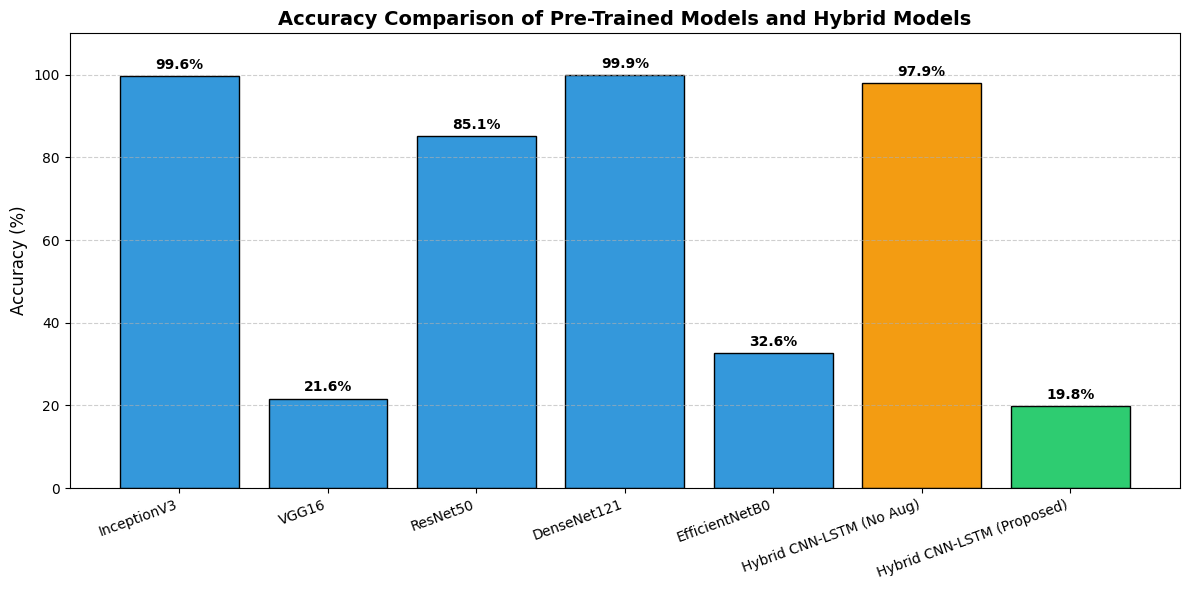

In [ ]:
# 3. Accuracy comparison of pre-trained models and hybrid model
plt.figure(figsize=(12, 6))
bars = plt.bar(models, df_all['Accuracy'], color=colors_acc, edgecolor='black')
plt.title('Accuracy Comparison of Pre-Trained Models and Hybrid Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)
plt.xticks(rotation=20, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.1f}%", ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




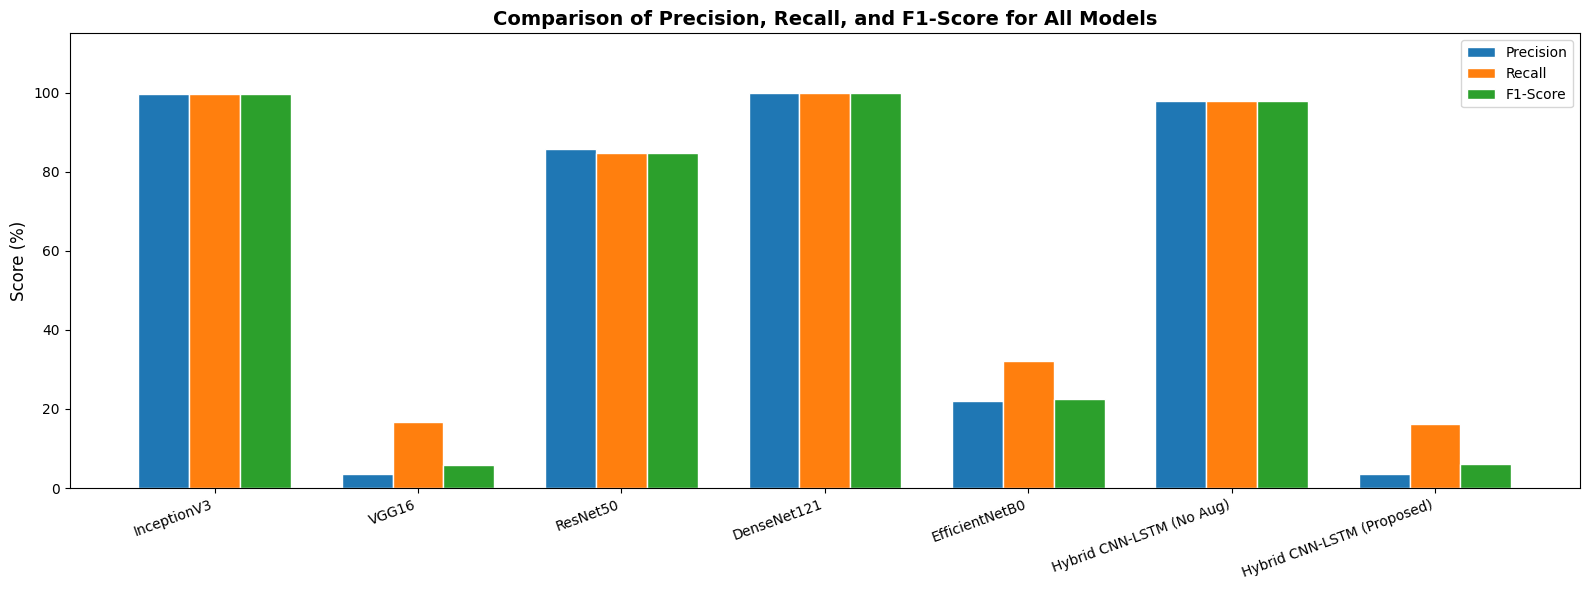

In [ ]:
# 4. Comparison of precision, recall, and F1-score for all models
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics):
    vals = df_all[metric]
    ax.bar(x + i*width - width, vals, width, label=metric, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 115)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Comparison of Precision, Recall, and F1-Score for All Models", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

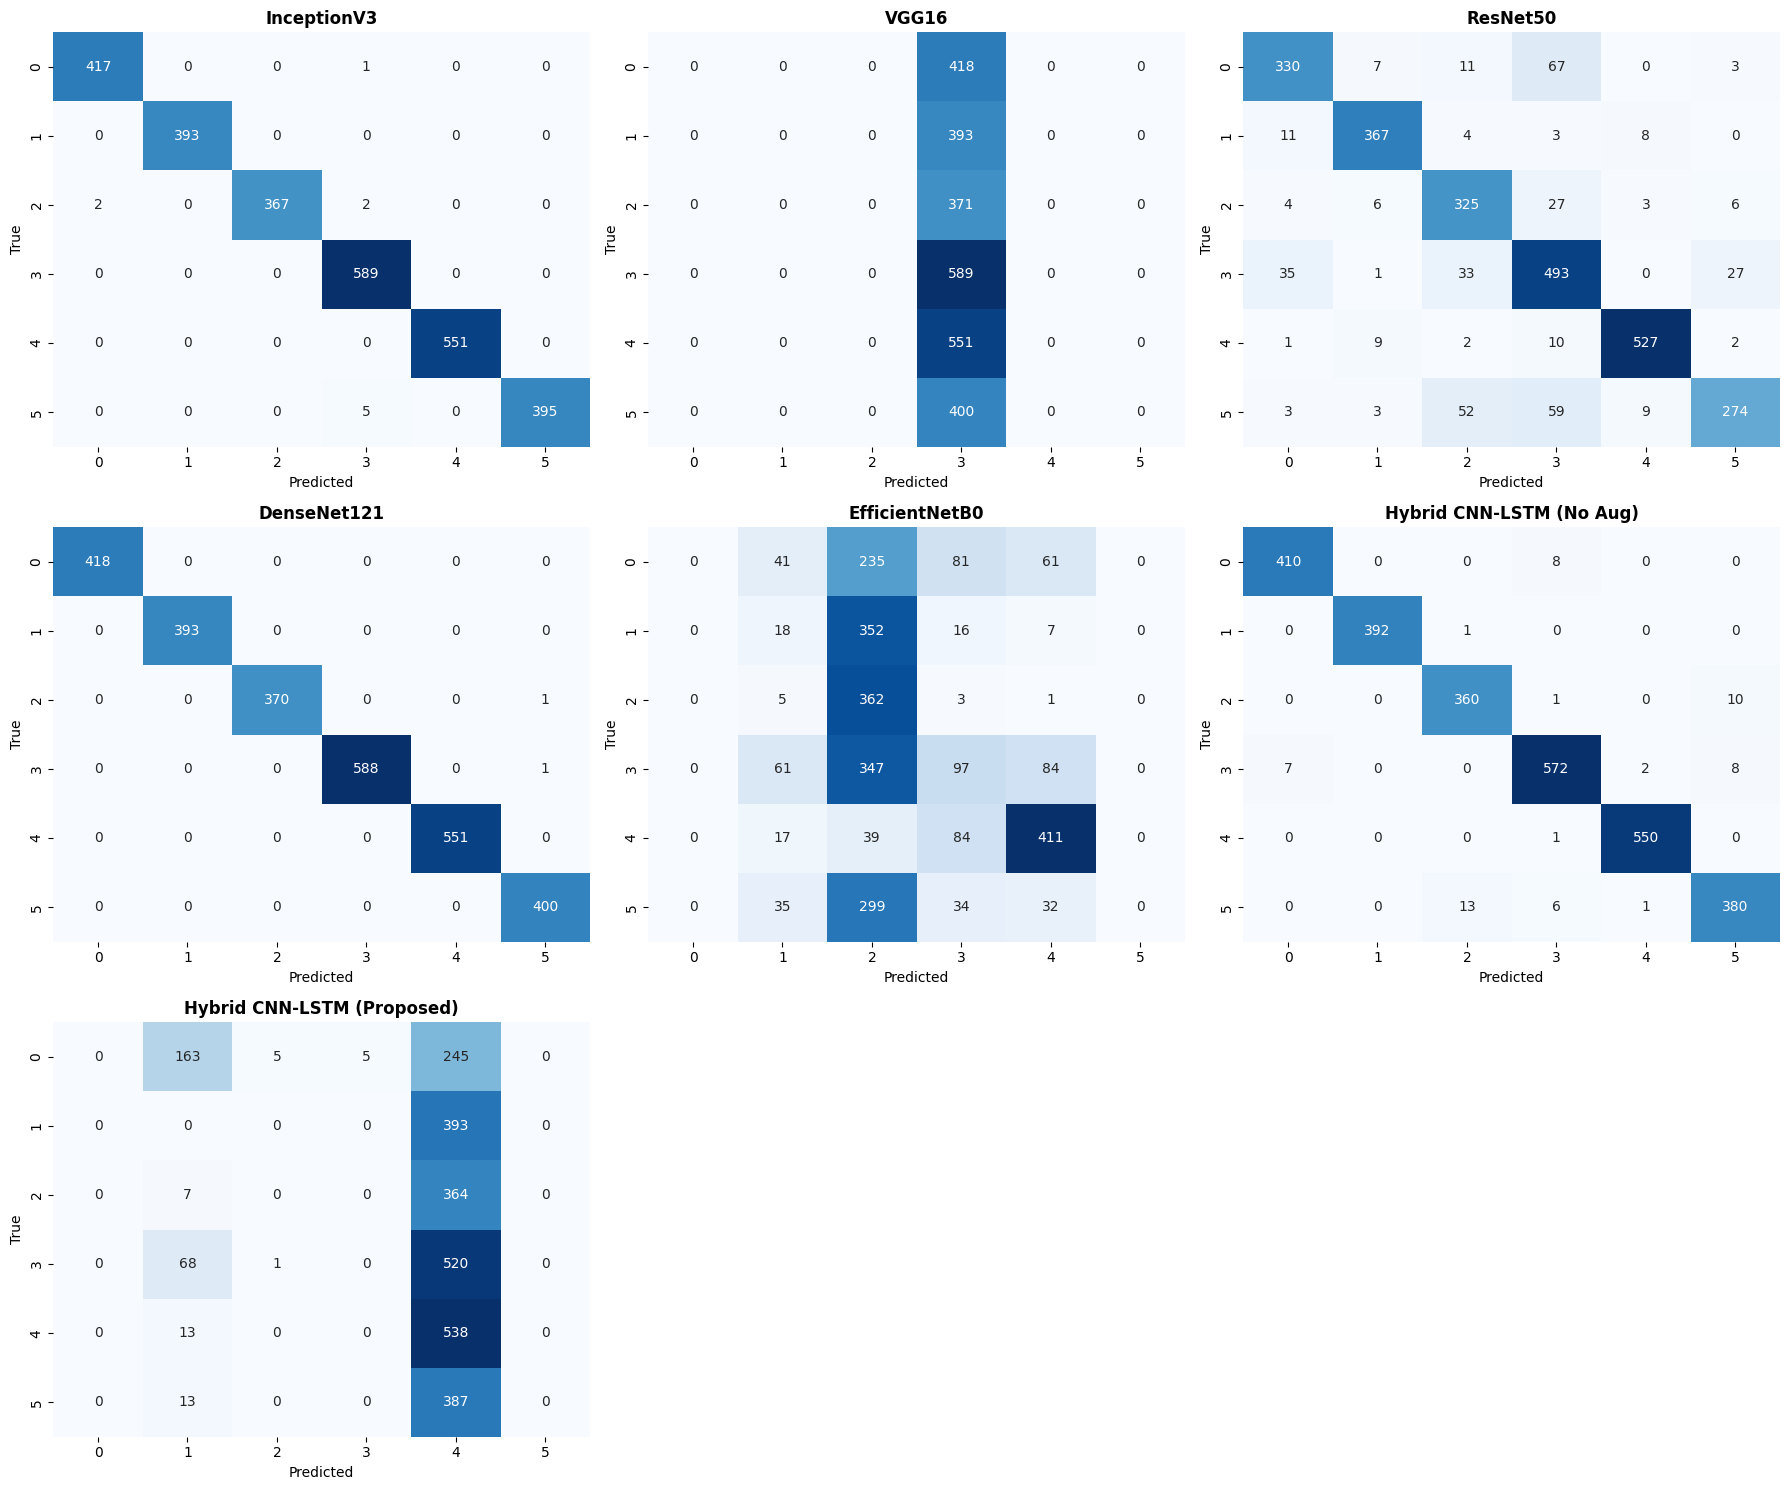

In [ ]:
# 5. Confusion matrix for all models
fig, axes = plt.subplots(3, 3, figsize=(18, 15)) # 7 Model için
axes = axes.ravel()
for idx, m_name in enumerate(models):
    cm = confusion_matrix(model_predictions[m_name]['y_true'], model_predictions[m_name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(m_name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
# Fazla olan grafikleri gizle
for idx in range(len(models), 9):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()



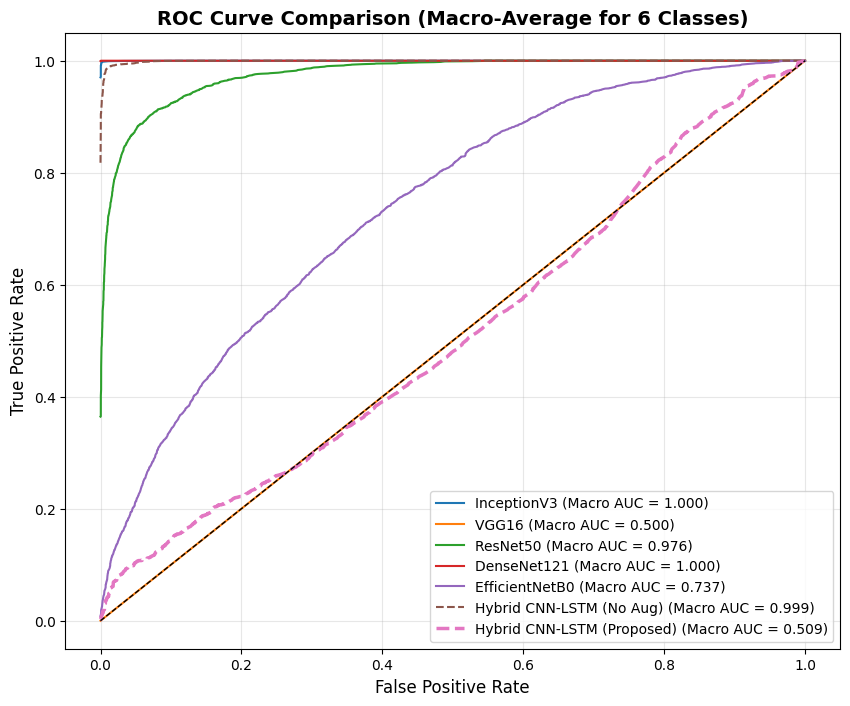

In [ ]:
# 6. ROC curve comparison for different models with AUC values (Macro Average)
plt.figure(figsize=(10, 8))
y_true_bin = label_binarize(model_predictions["Hybrid CNN-LSTM (Proposed)"]['y_true'], classes=np.arange(6))

for m_name in models:
    y_prob = model_predictions[m_name]['y_prob']
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(6):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(6)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(6):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= 6
    macro_auc = auc(all_fpr, mean_tpr)

    linestyle = '--' if "Hybrid" in m_name else '-'
    linewidth = 2.5 if m_name == "Hybrid CNN-LSTM (Proposed)" else 1.5
    plt.plot(all_fpr, mean_tpr, linestyle=linestyle, linewidth=linewidth, label=f"{m_name} (Macro AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison (Macro-Average for 6 Classes)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

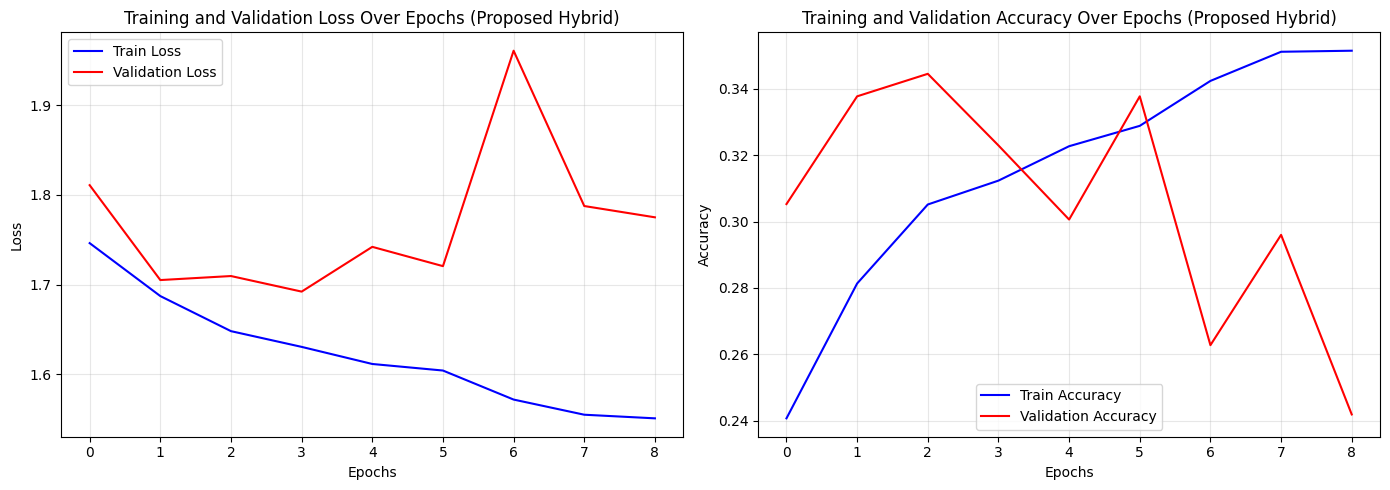

In [ ]:
# 7. Training and validation loss/accuracy over epochs (Proposed Model)
h = model_histories["Hybrid CNN-LSTM (Proposed)"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h['loss'], label='Train Loss', color='blue')
axes[0].plot(h['val_loss'], label='Validation Loss', color='red')
axes[0].set_title("Training and Validation Loss Over Epochs (Proposed Hybrid)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(h['val_accuracy'], label='Validation Accuracy', color='red')
axes[1].set_title("Training and Validation Accuracy Over Epochs (Proposed Hybrid)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



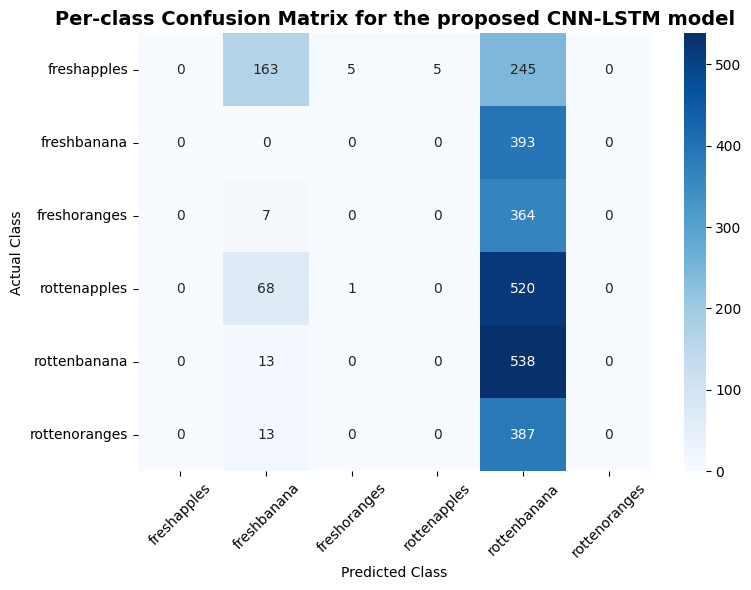

In [ ]:
# 8. Fig. 10 Per-class confusion matrix (Fresh vs. Rotten by fruit type) for the proposed CNN-LSTM model
cm_hybrid = confusion_matrix(model_predictions["Hybrid CNN-LSTM (Proposed)"]['y_true'], model_predictions["Hybrid CNN-LSTM (Proposed)"]['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Per-class Confusion Matrix for the proposed CNN-LSTM model', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()